In [1]:
import os
import sys
from pathlib import Path


def find_project_root(markers=("py_scripts", "examples_audio", "examples_csv")) -> Path:
	current_path = Path.cwd().resolve()
	for parent in [current_path, *current_path.parents]:
		if any((parent / m).is_dir() for m in markers):
			return parent
	raise RuntimeError(f"Could not locate project root containing one of {markers} above {current_path}")


# Resolve and expose project directories
PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
	sys.path.insert(0, str(PROJECT_ROOT))

EXAMPLES_AUDIO_DIR = PROJECT_ROOT / "examples_audio"
EXAMPLES_CSV_DIR = PROJECT_ROOT / "examples_csv"



In [2]:
from py_scripts.onset_generator import generate_onset_pattern
from py_scripts.audio_visualizer import load_audio, extract_features, visualize_features

Loading BokehJS ...

Loaded 'C:\Users\egorp\Nextcloud\code\public_repos\beat_it\examples_audio\Dufour_full_mono.aif' -> segment 36.000–42.000s of 77.667s @ 44100Hz


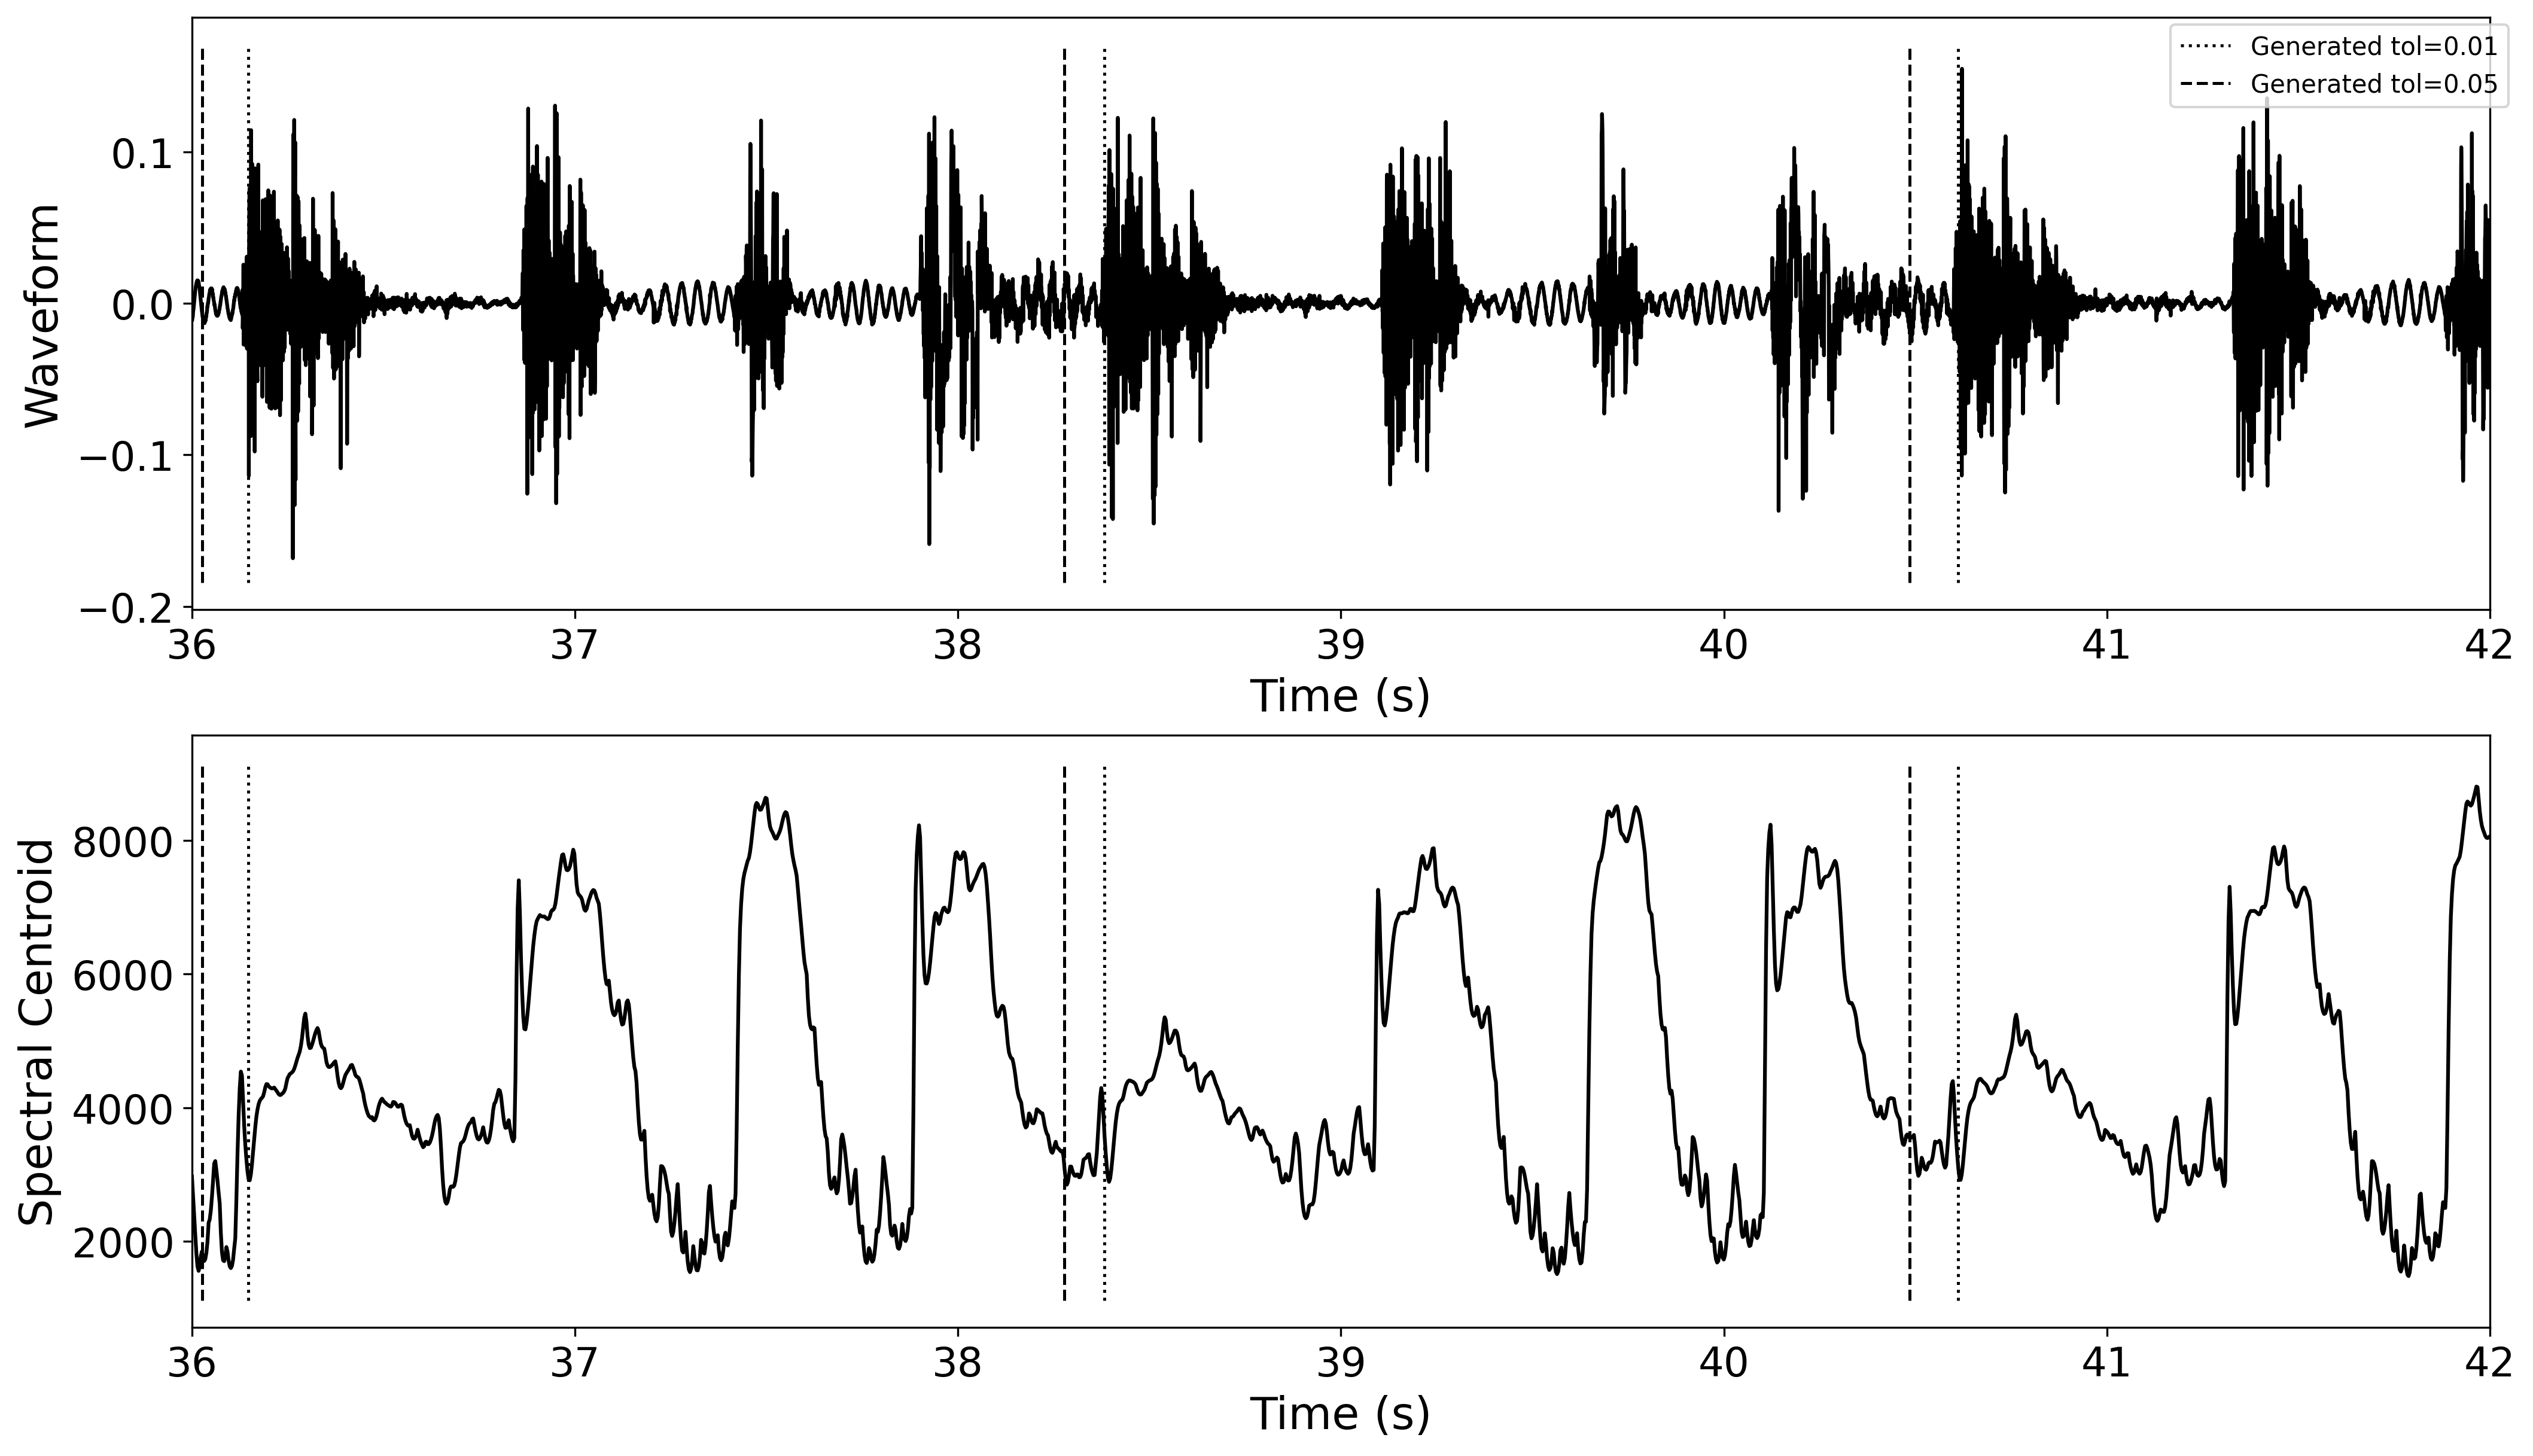

In [3]:
# --- BOKEH SETUP ---
from bokeh.io import output_notebook
output_notebook()
# --- END BOKEH SETUP ---


generated_onsets = generate_onset_pattern(
    pattern=2.233,
    start_time=0.4,        
    num_events=32,
    tolerance=0.01 
)

generated_onsets2 = generate_onset_pattern(
    pattern=2.233,
    start_time=0.4,        
    num_events=32,
    tolerance=0.02 
)

generated_onsets3 = generate_onset_pattern(
    pattern=2.233,
    start_time=0.4,        
    num_events=32,
    tolerance=0.05 
)

vocal_cues = generate_onset_pattern(
    pattern=[4.0, 0.5, 0.5], # A long pause followed by two quick entries
    start_time=2.0,
    num_events=6,
    tolerance=0.1
)

# 3. Structure them into the dictionary for plotting
onset_times_dict = {
#   "Manual GT": {
#     "times": onset_times1,
#     "color": "red",
#     "style": {"line_style": "solid", "line_width": 2.0, "tick_height": 0.1, "tick_position": "top", "marker": None}
#   },
#   "Librosa": {
#     "times": onset_times2,
#     "color": "magenta",
#     "style": {"line_style": "dashed", "line_width": 1.5, "marker": "triangle", "marker_size": 7}
#   },
  "Generated tol=0.01": {
    "times": generated_onsets,
    "color": "cyan",
    "style": {"line_style": "dotted", "line_width": 1.2}
  },
  "Generated tol=0.05": {
    "times": generated_onsets3,
    "color": "cyan",
    "style": {"line_style": "dashed", "line_width": 1.2}
  }
}

# Use absolute path to examples_audio
AUDIO_PATH = str(EXAMPLES_AUDIO_DIR / 'Dufour_full_mono.aif')
HOP_LENGTH = 128
N_FFT = 2048

# --- TIME RANGE ---
# Format: "HH:MM.SS-HH:MM.SS"
# Example: "00:00.000-00:20.000"
# If you want to plot the entire audio, use "None"
# If you want to plot a specific part of the audio, use the start and end times

TIME_RANGE = "00:36.000-00:42.000" 

# Ensure FEATURES_TO_PLOT is defined for this cell usage
FEATURES_TO_PLOT = ['waveform', 'spectral_centroid']

# 1. Load the audio file
y, sr = load_audio(AUDIO_PATH, time_range=TIME_RANGE)

feature_data = extract_features(
    y=y,
    sr=sr,
    hop_length=HOP_LENGTH,
    n_fft=N_FFT
)


# 4. Set the backend for the inline display: 'matplotlib' or 'bokeh'
PLOTTING_BACKEND = 'matplotlib'

# 5. Plot the computed features
visualize_features(
    features=feature_data,
    sr=sr,
    hop_length=HOP_LENGTH,
    onset_times=onset_times_dict,
    features_to_plot=FEATURES_TO_PLOT,
    backend=PLOTTING_BACKEND,
    time_range=TIME_RANGE,
    onsets_are_absolute=True,
    # new controls:
    grayscale=True,                 # switch to grayscale-friendly output
    grayscale_cmap='gray',          # colormap for spectrogram-type plots
    font_scale=1.8,                 # scale up all fonts
    # font_family='DejaVu Sans',      # or any installed font
    dpi=300                          # higher DPI for print
    # figsize=(8, 10),                # inches (width, height)
    # save_path='figures/dufour_features_gray.png'  # optional: save figure
)

In [4]:
print(generated_onsets)

[ 0.4         2.62721498  4.86700437  7.10511108  9.34089012 11.57734142
 13.80741787 16.04972354 18.29194653 20.52746727 22.75971554 24.9851461
 27.21767126 29.44966353 31.69076378 33.92152461 36.14680564 38.38240692
 40.6118274  42.83564719 45.07502931 47.30176125 49.53691792 51.76982541
 53.99688563 56.23541231 58.46979055 60.70934779 62.94884357 65.1792624
 67.42144322 69.6581042 ]


In [5]:
import pandas as pd

df1 = pd.read_csv(str(EXAMPLES_CSV_DIR / 'dufour_manual.csv'))
display(df1)

df2 = pd.read_csv(str(EXAMPLES_CSV_DIR / 'dufour_onsets_librosa_filtered.csv'))
display(df2)


,peaks_in_sec
0,0.398730
1,2.623492
2,4.863492
3,7.080635
4,9.340952
5,11.553016
6,13.782857
7,16.017778
8,18.245079
9,20.490159


,seq1
0,0.400544
1,2.618050
2,4.858776
3,7.082086
4,9.322812
5,11.528707
6,13.775238
7,16.015964
8,18.210249
9,20.485805


Loading BokehJS ...

Loaded 'C:\Users\egorp\Nextcloud\code\public_repos\beat_it\examples_audio\Dufour_full_mono.aif' -> segment 36.000–42.000s of 77.667s @ 44100Hz


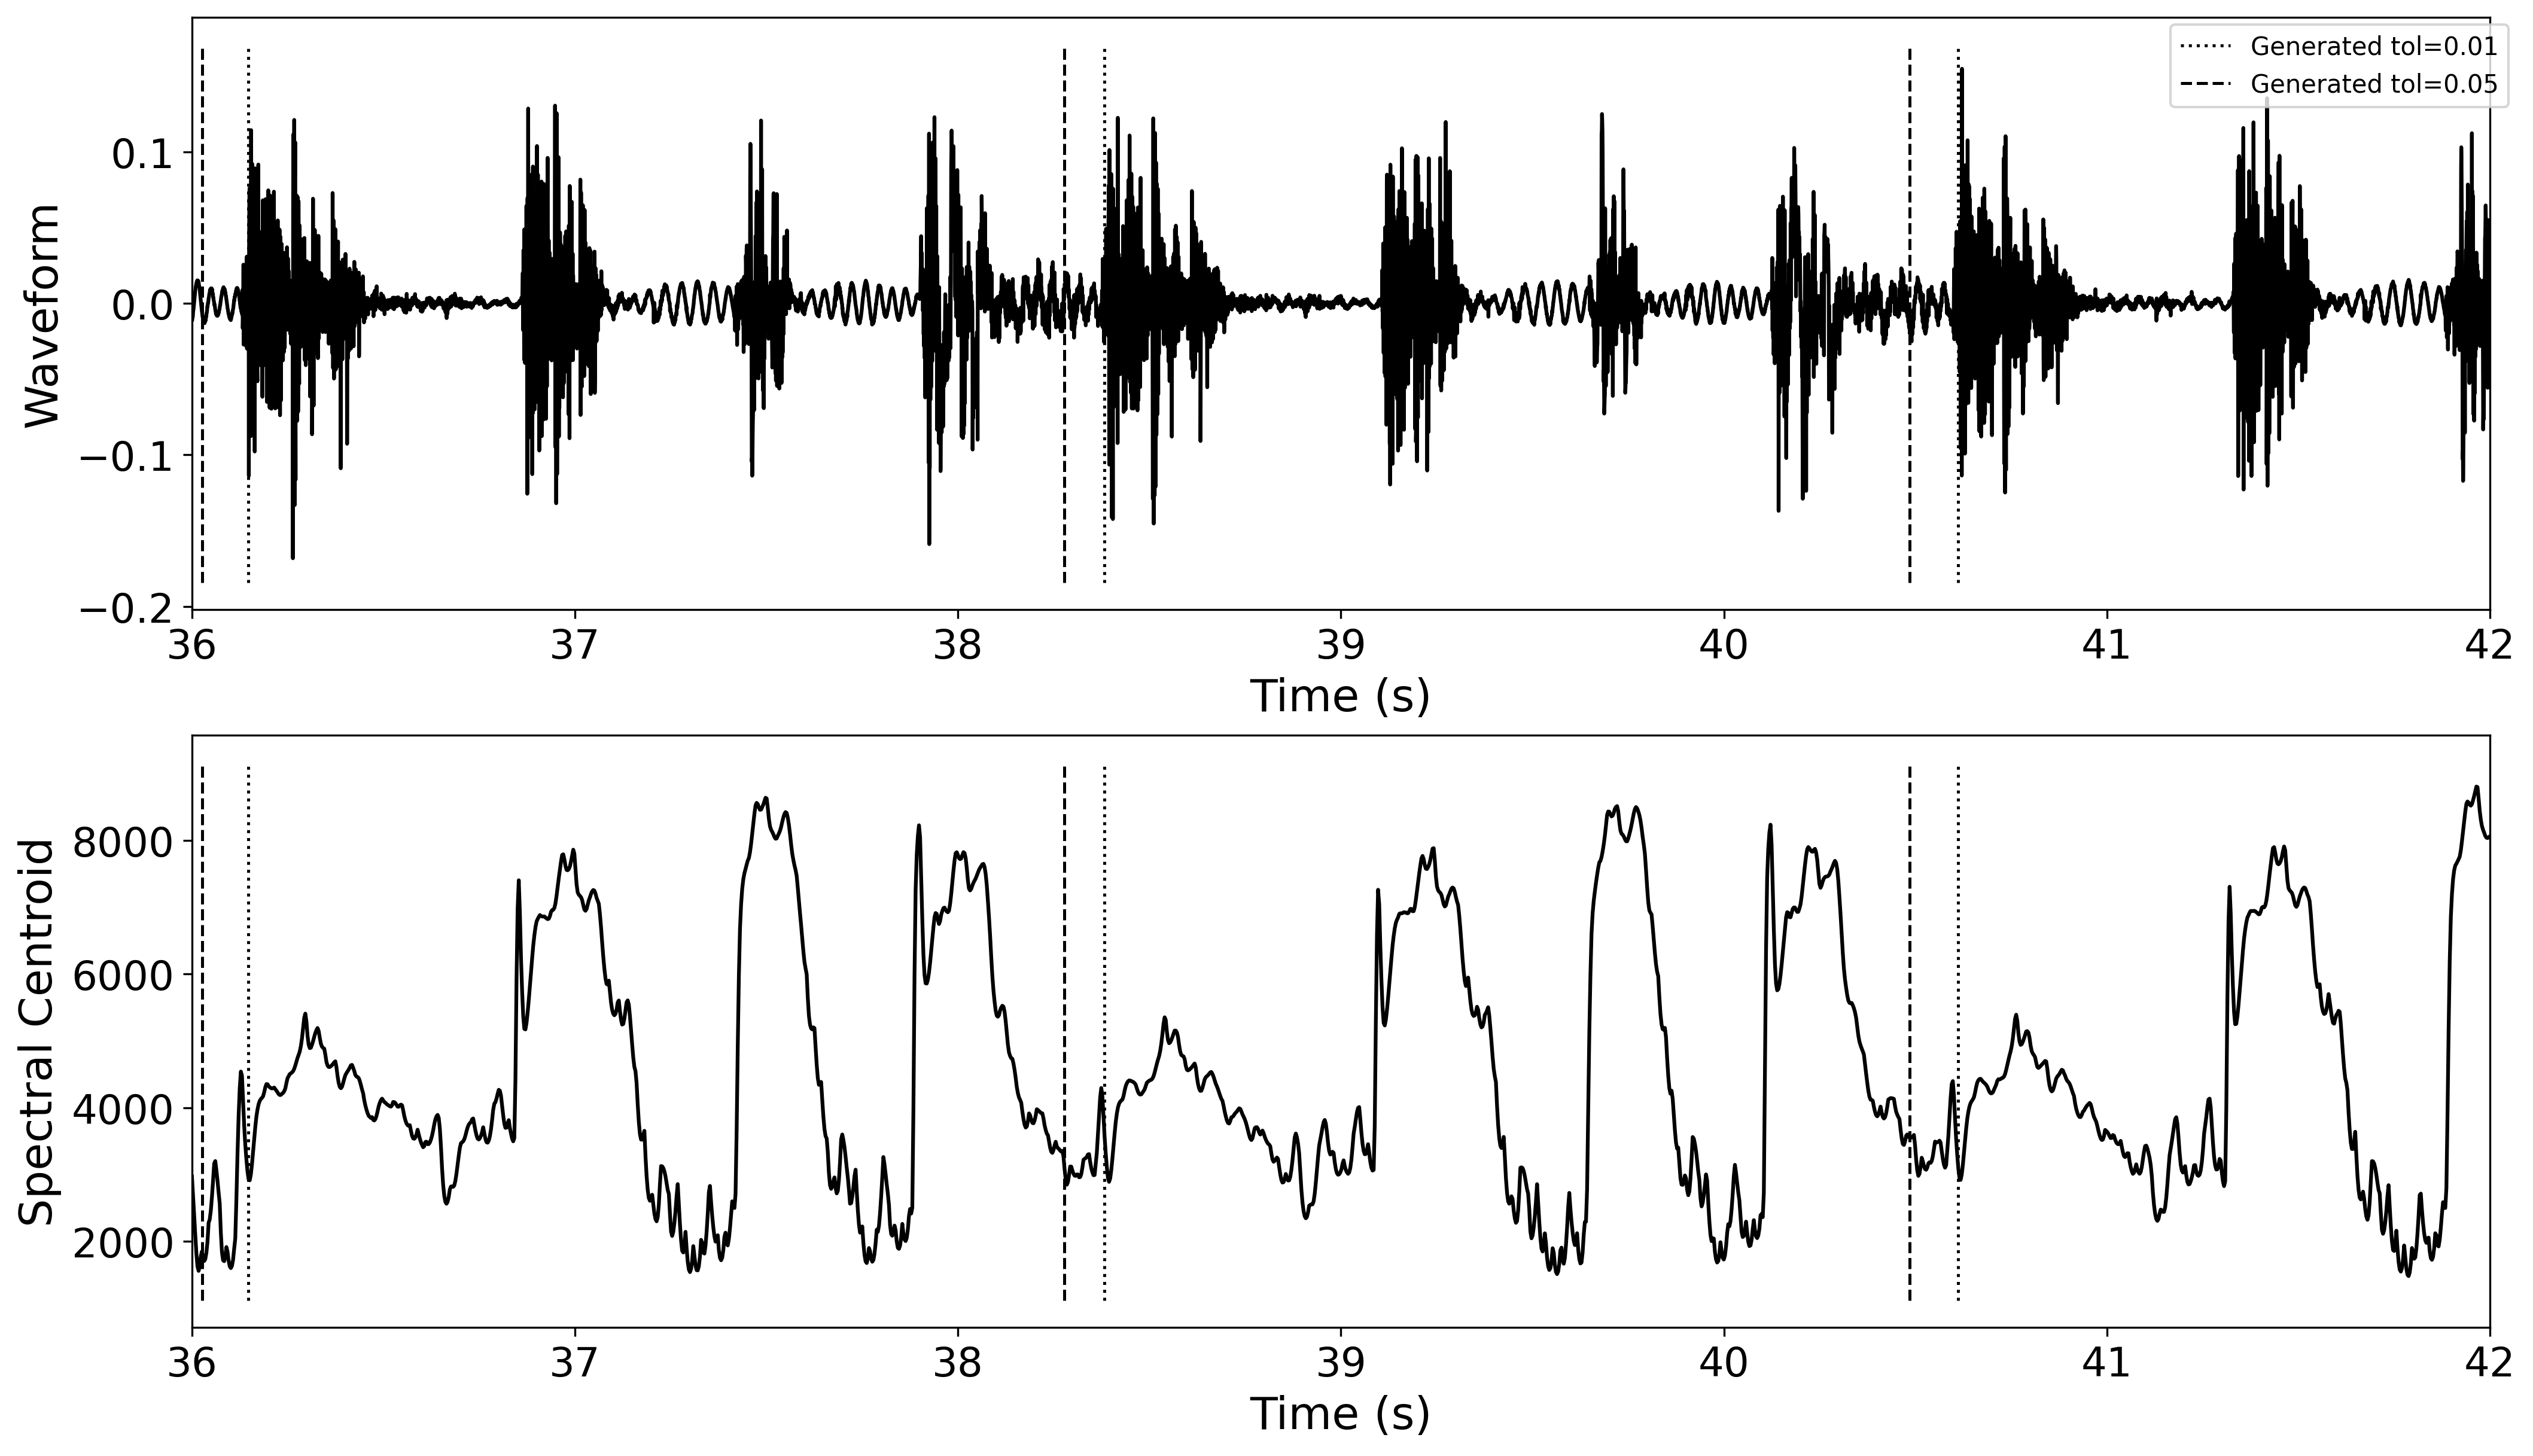

In [ ]:
# --- BOKEH SETUP ---
from bokeh.io import output_notebook
output_notebook()
# --- END BOKEH SETUP ---


generated_onsets = generate_onset_pattern(
    pattern=2.233,
    start_time=0.4,        
    num_events=32,
    tolerance=0.01 
)

generated_onsets2 = generate_onset_pattern(
    pattern=2.233,
    start_time=0.4,        
    num_events=32,
    tolerance=0.02 
)

generated_onsets3 = generate_onset_pattern(
    pattern=2.233,
    start_time=0.4,        
    num_events=32,
    tolerance=0.05 
)

vocal_cues = generate_onset_pattern(
    pattern=[4.0, 0.5, 0.5], # A long pause followed by two quick entries
    start_time=2.0,
    num_events=6,
    tolerance=0.1
)

# 3. Structure them into the dictionary for plotting
onset_times_dict = {
#   "Manual GT": {
#     "times": onset_times1,
#     "color": "red",
#     "style": {"line_style": "solid", "line_width": 2.0, "tick_height": 0.1, "tick_position": "top", "marker": None}
#   },
#   "Librosa": {
#     "times": onset_times2,
#     "color": "magenta",
#     "style": {"line_style": "dashed", "line_width": 1.5, "marker": "triangle", "marker_size": 7}
#   },
  "Generated tol=0.01": {
    "times": generated_onsets,
    "color": "cyan",
    "style": {"line_style": "dotted", "line_width": 1.2}
  },
  "Generated tol=0.05": {
    "times": generated_onsets3,
    "color": "cyan",
    "style": {"line_style": "dashed", "line_width": 1.2}
  }
}

# Use absolute path to examples_audio
AUDIO_PATH = str(EXAMPLES_AUDIO_DIR / 'Dufour_full_mono.aif')
HOP_LENGTH = 128
N_FFT = 2048

# --- TIME RANGE ---
# Format: "HH:MM.SS-HH:MM.SS"
# Example: "00:00.000-00:20.000"
# If you want to plot the entire audio, use "None"
# If you want to plot a specific part of the audio, use the start and end times

TIME_RANGE = "00:36.000-00:42.000" 

# Ensure FEATURES_TO_PLOT is defined for this cell usage
FEATURES_TO_PLOT = ['waveform', 'spectral_centroid']

# 1. Load the audio file
y, sr = load_audio(AUDIO_PATH, time_range=TIME_RANGE)

feature_data = extract_features(
    y=y,
    sr=sr,
    hop_length=HOP_LENGTH,
    n_fft=N_FFT
)


# 4. Set the backend for the inline display: 'matplotlib' or 'bokeh'
PLOTTING_BACKEND = 'matplotlib'

# 5. Plot the computed features
visualize_features(
    features=feature_data,
    sr=sr,
    hop_length=HOP_LENGTH,
    onset_times=onset_times_dict,
    features_to_plot=FEATURES_TO_PLOT,
    backend=PLOTTING_BACKEND,
    time_range=TIME_RANGE,
    onsets_are_absolute=True,
    # new controls:
    grayscale=True,                 # switch to grayscale-friendly output
    grayscale_cmap='gray',          # colormap for spectrogram-type plots
    font_scale=1.8,                 # scale up all fonts
    # font_family='DejaVu Sans',      # or any installed font
    dpi=300                          # higher DPI for print
    # figsize=(8, 10),                # inches (width, height)
    # save_path='figures/dufour_features_gray.png'  # optional: save figure
)

In [6]:
onset_times1 = df1['peaks_in_sec'].tolist()
print(onset_times1)

onset_times2 = df2['seq1'].tolist()
print(onset_times2)

[0.398730159, 2.623492063, 4.863492063, 7.080634921, 9.340952381, 11.553015873, 13.782857143, 16.017777778, 18.245079365, 20.49015873, 22.70984127, 24.954920635, 27.182222222, 29.424761905, 31.641904762, 33.881904762, 36.12952381, 38.38984127, 40.604444444, 42.852063492, 45.074285714, 47.311746032, 49.536507937, 51.781587302, 53.998730159, 56.236190476, 58.466031746, 60.693333333, 62.938412698, 65.158095238, 67.408253968, 69.627936508]
[0.4005442176870748, 2.618049886621315, 4.858775510204081, 7.082086167800454, 9.32281179138322, 11.528707482993198, 13.775238095238096, 16.015963718820863, 18.210249433106576, 20.48580498866213, 22.709115646258503, 24.9556462585034, 27.17315192743764, 29.41968253968254, 31.642993197278912, 33.88952380952381, 36.11283446712018, 38.376780045351474, 40.600090702947846, 42.84081632653061, 45.06993197278912, 47.31065759637188, 49.533968253968254, 51.78049886621315, 53.9980045351474, 56.24453514739229, 58.46784580498866, 60.67374149659864, 62.93768707482993, 6

In [7]:


# The new data structure for our functions
cue_lists = {
    "Manual Ground Truth": onset_times1,
    "Librosa Onsets": onset_times2
    # "Generated Onsets, tol=0.01": generated_onsets,
    # "Generated Onsets 2, tol=0.02": generated_onsets2,
    # "Generated Onsets 3, tol=0.05": generated_onsets3
}

# The key for the reference list
ground_truth_key = "Manual Ground Truth" 

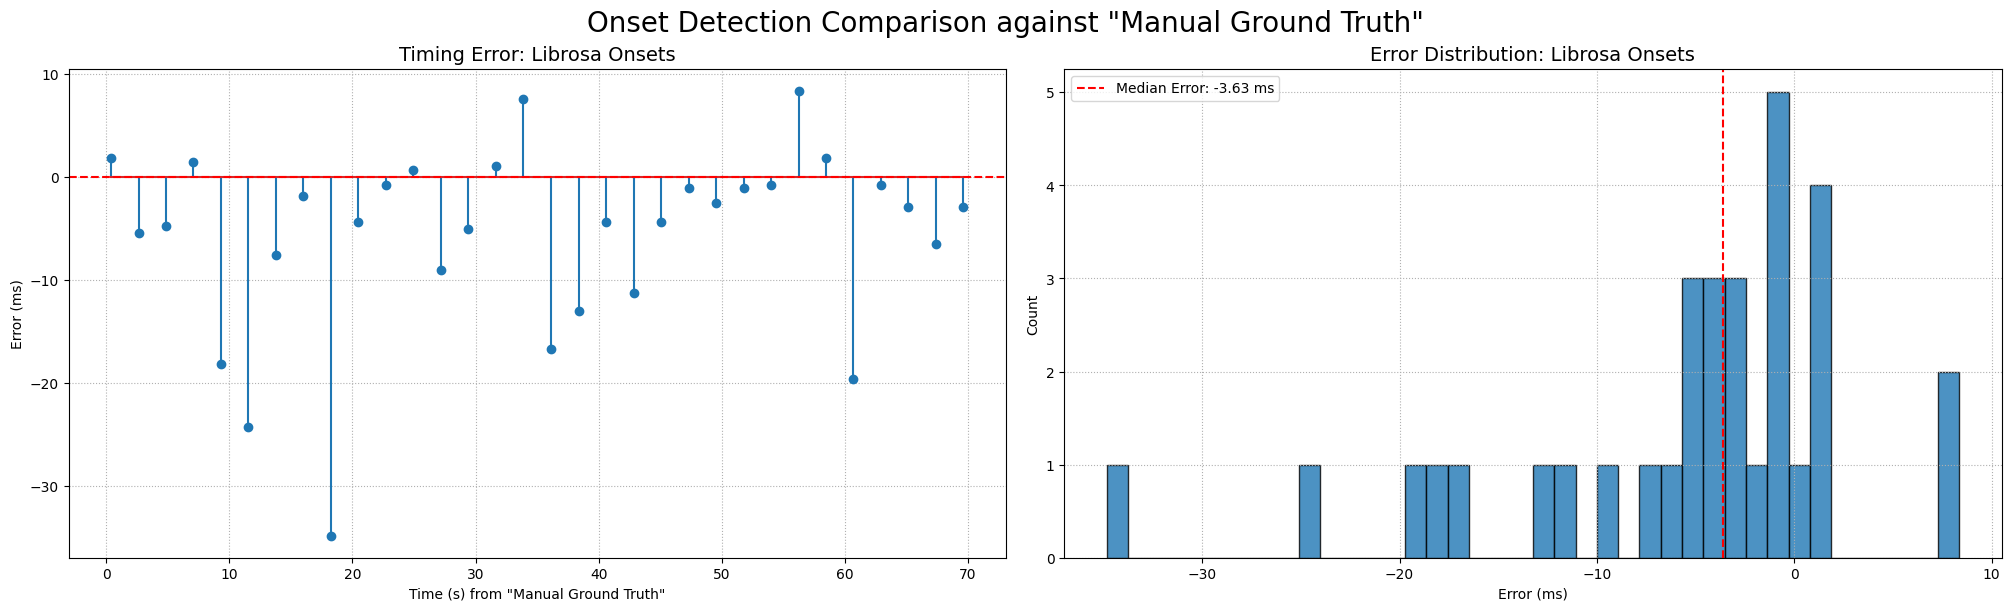

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict, List

def visualize_multi_onset_differences(
    cue_lists: Dict[str, List[float]], 
    ground_truth_key: str
):
    """
    Creates a dashboard to compare multiple detected onset lists against a single ground truth,
    using constrained_layout for robust spacing.
    """
    if ground_truth_key not in cue_lists:
        raise ValueError(f"The ground_truth_key '{ground_truth_key}' was not found in the cue_lists dictionary.")

    truth_times = np.array(cue_lists[ground_truth_key])
    detected_keys = [key for key in cue_lists if key != ground_truth_key]
    
    if not detected_keys:
        print("No other lists to compare against the ground truth.")
        return

    n_rows = len(detected_keys)
    
    # --- The key change is enabling constrained_layout=True here ---
    fig, axes = plt.subplots(n_rows, 2, figsize=(20, 6 * n_rows), 
                             squeeze=False, constrained_layout=True)
                             
    fig.suptitle(f'Onset Detection Comparison against "{ground_truth_key}"', fontsize=20)

    for i, key in enumerate(detected_keys):
        # ... (The rest of the plotting logic inside the loop is identical) ...
        detected_times = np.array(cue_lists[key])
        min_len = min(len(truth_times), len(detected_times))
        truth_sliced = truth_times[:min_len]
        detected_sliced = detected_times[:min_len]
        error_ms = (detected_sliced - truth_sliced) * 1000

        # Plot 1: Timing Error
        ax1 = axes[i, 0]
        ax1.stem(truth_sliced, error_ms)
        ax1.axhline(0, color='r', linestyle='--')
        ax1.set_title(f'Timing Error: {key}', fontsize=14)
        ax1.set_xlabel(f'Time (s) from "{ground_truth_key}"')
        ax1.set_ylabel('Error (ms)')
        ax1.grid(True, linestyle=':')

        # Plot 2: Histogram
        ax2 = axes[i, 1]
        ax2.hist(error_ms, bins=40, alpha=0.8, edgecolor='black')
        median_error = np.median(error_ms)
        ax2.axvline(median_error, color='r', linestyle='--', label=f'Median Error: {median_error:.2f} ms')
        ax2.set_title(f'Error Distribution: {key}', fontsize=14)
        ax2.set_xlabel('Error (ms)')
        ax2.set_ylabel('Count')
        ax2.legend()
        ax2.grid(True, linestyle=':')

    # --- The old tight_layout() call is removed ---
    plt.show()

# --- HOW TO USE ---
visualize_multi_onset_differences(cue_lists, ground_truth_key)

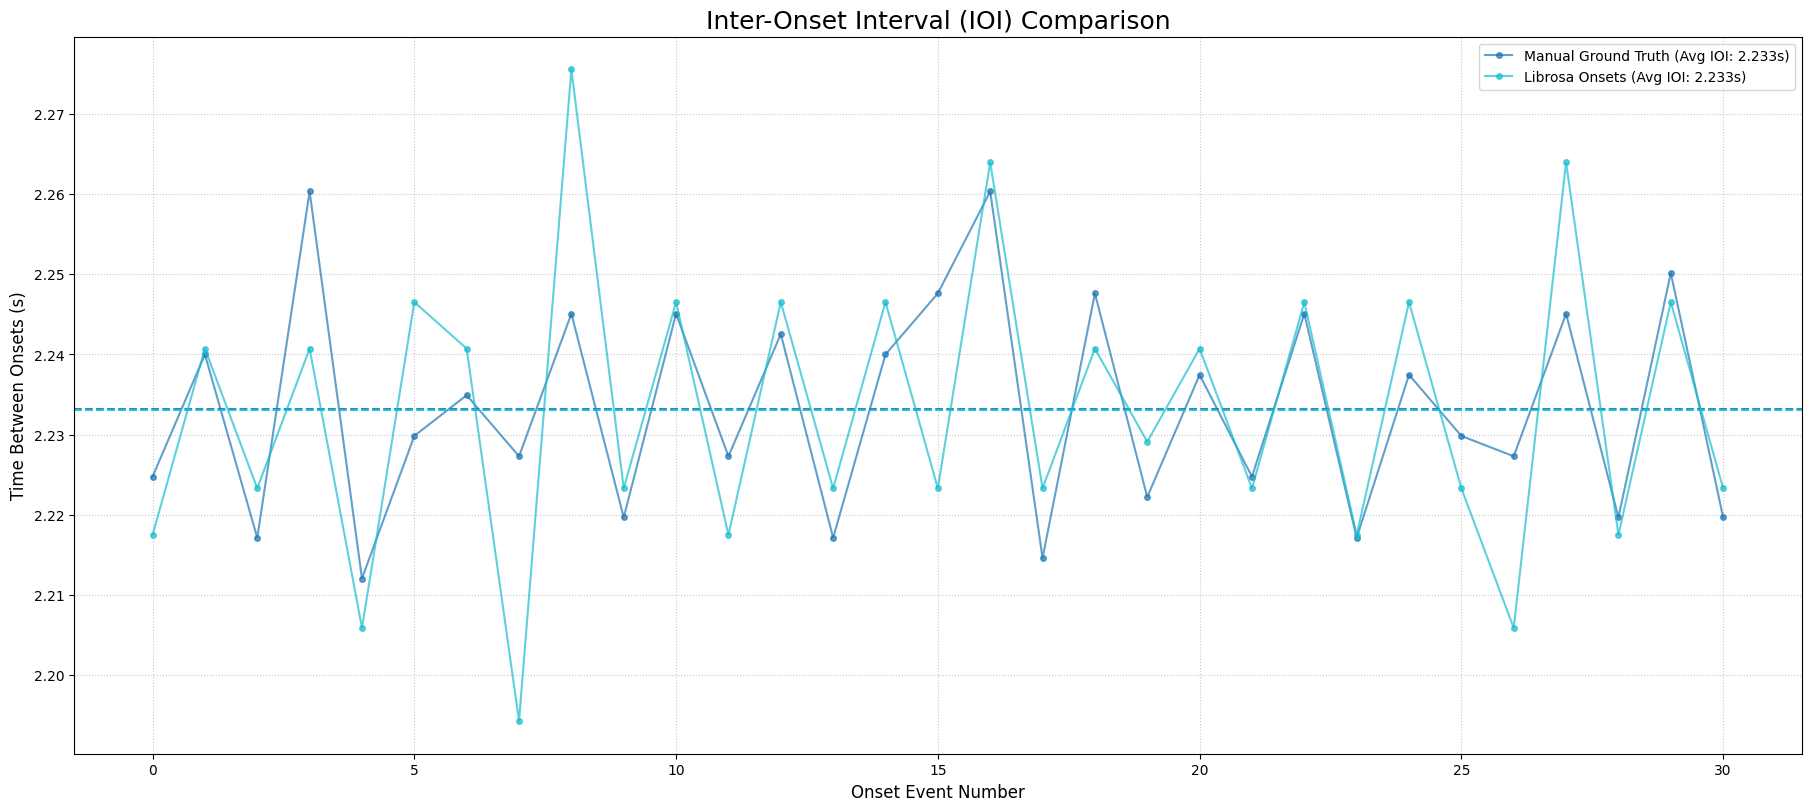

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List

def plot_multi_ioi_comparison(cue_lists: Dict[str, List[float]]):
    """
    Calculates and plots the Inter-Onset Intervals (IOI) for multiple lists,
    using constrained_layout for robust legend placement.
    """
    # The key change is creating the figure and axes with constrained_layout=True
    fig, ax = plt.subplots(figsize=(18, 8), constrained_layout=True)
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(cue_lists)))

    for i, (label, times) in enumerate(cue_lists.items()):
        if len(times) < 2:
            print(f"Warning: List '{label}' has fewer than 2 onsets, cannot calculate IOI. Skipping.")
            continue
            
        ioi = np.diff(np.array(times))
        avg_ioi = np.mean(ioi)
        legend_label = f'{label} (Avg IOI: {avg_ioi:.3f}s)'
        
        ax.plot(ioi, marker='o', linestyle='-', markersize=4, 
                label=legend_label, color=colors[i], alpha=0.7)
        ax.axhline(y=avg_ioi, color=colors[i], linestyle='--', alpha=0.9)

    ax.set_title('Inter-Onset Interval (IOI) Comparison', fontsize=18)
    ax.set_xlabel('Onset Event Number', fontsize=12)
    ax.set_ylabel('Time Between Onsets (s)', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.7)
    
    # A simple legend call is now sufficient. constrained_layout will make room for it.
    ax.legend()
    
    # We no longer need the plt.tight_layout() call.
    plt.show()

# --- HOW TO USE ---
plot_multi_ioi_comparison(cue_lists)

In [10]:
# # Save selected sequence as CSV

# import os

# # 1. Define the filename
# filename = "best_sequence.csv"

# # 2. Save the array to the CSV file
# np.savetxt(filename, best_seq, delimiter=",")

# # 3. Get the full, absolute path of the file
# full_path = os.path.abspath(filename)

# # 4. Print the confirmation message with the full path
# print(f"The best sequence has been saved to: {full_path}")

In [11]:
onset_times_dict = {
    "Manual (GT)": {
        "times": onset_times1,
        "color": "red",  # ignored in grayscale
        "style": {
            "line_style": "solid",
            "line_width": 1.5
        }
    },
    "Librosa": {
        "times": onset_times2,
        "color": "magenta",  # ignored in grayscale
        "style": {
            "line_style": "dotted",  # or use "dashed" with dash_pattern below
            "line_width": 1.5
        }
    }
}

In [ ]:
# Import the necessary functions from your module
from py_scripts.audio_visualizer import load_audio, extract_features, visualize_features
import numpy as np

# --- BOKEH SETUP ---
from bokeh.io import output_notebook
output_notebook()
# --- END BOKEH SETUP ---

# Use absolute path to examples_audio
AUDIO_PATH = str(EXAMPLES_AUDIO_DIR / 'Dufour_full_mono.aif')
HOP_LENGTH = 128
N_FFT = 2048

# --- TIME RANGE ---
# Format: "HH:MM.SS-HH:MM.SS"
# Example: "00:00.000-00:20.000"
# If you want to plot the entire audio, use "None"
# If you want to plot a specific part of the audio, use the start and end times

TIME_RANGE = "00:37.200-00:39.500" 

# Ensure FEATURES_TO_PLOT is defined for this cell usage
FEATURES_TO_PLOT = ['waveform', 'spectral_centroid']

# 1. Load the audio file
y, sr = load_audio(AUDIO_PATH, time_range=TIME_RANGE)

feature_data = extract_features(
    y=y,
    sr=sr,
    hop_length=HOP_LENGTH,
    n_fft=N_FFT
)


# 4. Set the backend for the inline display: 'matplotlib' or 'bokeh'
PLOTTING_BACKEND = 'bokeh'

# 5. Plot the computed features
visualize_features(
    features=feature_data,
    sr=sr,
    hop_length=HOP_LENGTH,
    onset_times=onset_times_dict,
    features_to_plot=FEATURES_TO_PLOT,
    backend=PLOTTING_BACKEND,
    time_range=TIME_RANGE,
    onsets_are_absolute=True,
    # new controls:
    grayscale=True,                 # switch to grayscale-friendly output
    grayscale_cmap='gray',          # colormap for spectrogram-type plots
    font_scale=1.8,                 # scale up all fonts
    # font_family='DejaVu Sans',      # or any installed font
    dpi=300,                          # higher DPI for print
    # figsize=(8, 10),                # inches (width, height)
    # save_path='figures/dufour_features_gray.png'  # optional: save figure
    show_legend=False
)

Loading BokehJS ...

Loaded 'C:\Users\egorp\Nextcloud\code\public_repos\beat_it\examples_audio\Dufour_full_mono.aif' -> segment 37.200–39.500s of 77.667s @ 44100Hz
